In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.manifold import Isomap, SpectralEmbedding

from geodesic_toolbox.cometric import CentroidsCometric, IdentityCoMetric, RandersMetrics
from geodesic_toolbox.utils import get_mf_image

from finsler_embedding.utils import get_grid_pts, get_bounds
from finsler_embedding.omega import get_omega
from finsler_embedding.graph import construct_distance_matrix, get_knn_graph,compute_epsilon_empirical
from finsler_embedding.operators import *


/home/tblanchard/phd/Finsler-Embedding/.venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
def get_spiral(n_pts: int, freq: float, sigma: float = 0.1, t_max: float = 4 * np.pi,device: str = "cpu") -> tuple[torch.Tensor, torch.Tensor]:
    # Sample uniformly in arc length on the noiseless spiral, then add noise.
    t_dense = np.linspace(0.0, t_max, max(5000, 10 * n_pts))
    speed = np.sqrt(1.0 + (freq * t_dense) ** 2)
    ds = 0.5 * (speed[1:] + speed[:-1]) * np.diff(t_dense)
    s_dense = np.concatenate(([0.0], np.cumsum(ds)))
    s_uniform = np.linspace(0.0, s_dense[-1], n_pts)
    t = np.interp(s_uniform, s_dense, t_dense)

    x = t * np.cos(freq * t) + np.random.normal(0, sigma, n_pts)
    y = t * np.sin(freq * t) + np.random.normal(0, sigma, n_pts)
    X = np.stack([x, y], axis=1)

    # Normalize the data
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    s = s_uniform / s_uniform[-1]
    X = torch.from_numpy(X).double().to(device)
    s = torch.from_numpy(s).double().to(device)
    return X, s


In [3]:
N = 2000
m = 2
eps_scale = 10.0
beta=0.5

X,t = get_spiral(N, freq=1.0, sigma=0.2, t_max=4 * np.pi)
idx = torch.randperm(X.shape[0])
X = X[idx].float()
t = t[idx]

bounds_high = get_bounds(X, margin=0.1)

In [4]:
base_cometric = IdentityCoMetric()
base_cometric = CentroidsCometric(centroids=X, cometric_centroids=base_cometric(X))
omega_true = get_omega("spiral",cometric=base_cometric)
randers_metric = RandersMetrics(
    base_cometric=base_cometric,
    omega=omega_true,
    beta=beta,
)
mf = get_mf_image(base_cometric, X,bounds=bounds_high)

Computing magnification factor: 100%|██████████| 79/79 [00:00<00:00, 294.11batch/s]


In [5]:
edges = get_knn_graph(X, n_neighbors=10)
print(f"Found {edges.shape[0]} edges in the KNN graph.")
dst_edges = construct_distance_matrix(X, edges, randers_metric,use_approx=True)


Found 23932 edges in the KNN graph.


Computing Randers distances:   0%|          | 0/240 [00:00<?, ?it/s]

Computing Randers distances: 100%|██████████| 240/240 [00:03<00:00, 66.82it/s]


In [6]:
# X_low = None
# X_low = Isomap(n_neighbors=10, n_components=2).fit_transform(X)
X_low = SpectralEmbedding(n_neighbors=10, n_components=2).fit_transform(X)
X_low = torch.from_numpy(X_low).float()
bounds = get_bounds(X_low,margin=0.1)

In [7]:
epsilon = compute_epsilon_empirical(dst_edges, scale=eps_scale)
W = apply_gaussian_kernel(edges,dst_edges, epsilon,N)
results = randers_approximation(W, epsilon,X_low=X_low, m=m)
V = results["V"]
V_normed = V / (results["c_norm_sq"].sqrt() + 1e-12).unsqueeze(1)
unit_V = V / (V.norm(dim=1, keepdim=True) + 1e-12)
X_low = results["X_low"]

In [8]:
# Sort by x coords for display
idx = torch.argsort(X_low[:, 0])
X_low_plt = X_low[idx].clone()
V_plt = V[idx].clone()
unit_V_plt = unit_V[idx].clone()
t_plt = t[idx]

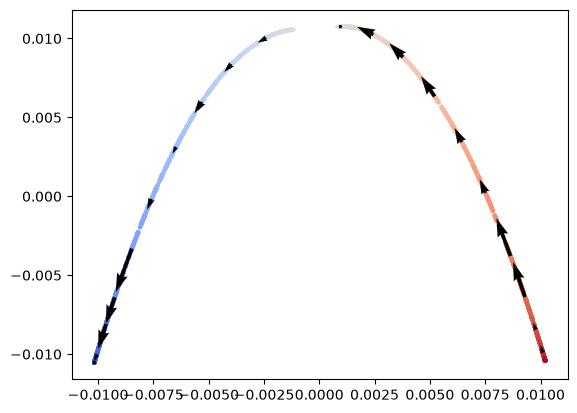

In [9]:
cbar = plt.scatter(
    X_low_plt[:, 0], X_low_plt[:, 1], c=t_plt, cmap="coolwarm",s=5
)
skip=100
plt.quiver(
    X_low_plt[::skip, 0],
    X_low_plt[::skip, 1],
    # unit_V_plt[::skip, 0],
    # unit_V_plt[::skip, 1],
    V_plt[::skip, 0],
    V_plt[::skip, 1],
    color="black",
    scale=0.1,
    angles="xy",
    scale_units="xy",
)

In [10]:
model, loss_list = interpolate_V(X_low, V, dim=m)
# model, loss_list = interpolate_V(X_low, V_normed, dim=m, n_epochs=5000)

  0%|          | 0/500 [00:00<?, ?it/s]

Loss: 0.0000: 100%|██████████| 500/500 [00:01<00:00, 280.83it/s]


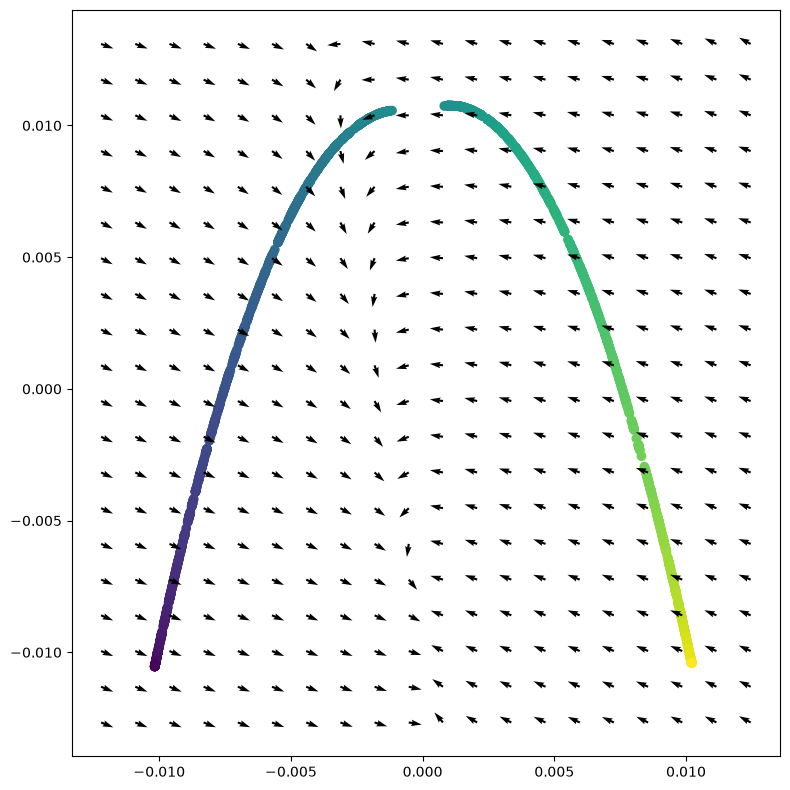

In [11]:
# Grid
grid_points = get_grid_pts(bounds, n_pts=20)
# grid_points += 1e-1 * torch.randn_like(grid_points)
V_grid = model(grid_points).detach()
V_grid_unit = V_grid / (V_grid.norm(dim=1, keepdim=True) + 1e-12)

plt.figure(figsize=(8, 8))
plt.scatter(X_low[:, 0], X_low[:, 1], c=t, cmap=plt.cm.viridis)
plt.quiver(
    grid_points[:, 0],
    grid_points[:, 1],
    V_grid_unit[:, 0],
    V_grid_unit[:, 1],
    color="black",
    scale=2000,
    angles="xy",
    scale_units="xy",
)
plt.xlim(bounds[0], bounds[1])
plt.ylim(bounds[2], bounds[3])
plt.tight_layout()
plt.axis("equal")
plt.show()